# **Libraries**

In [5]:
import numpy as np
import os
import zipfile
import cv2 as cv
import matplotlib.pyplot as plt
from google.colab import drive
from google.colab.patches import cv2_imshow
from sklearn.model_selection import train_test_split

In [6]:
plt.style.use("dark_background")

In [7]:
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
#Path in drive
dataset_zip_path='/content/drive/MyDrive/VideoClassification/Shop DataSet.zip'
zipfile_obj=zipfile.ZipFile(dataset_zip_path,'r')
zipfile_obj.extractall('/content')
zipfile_obj.close()

In [9]:
dataset_path="/content/Shop DataSet"
#dataset_path = "C:/Users/nadak/Downloads/Shop DataSet"

In [10]:
FRAMES =16
WIDTH=128
HEIGHT=128

# **Dataset overview**

In [11]:
class_names = os.listdir(dataset_path)
num_classes=len(class_names)
class_paths =[os.path.join(dataset_path,class_path) for class_path in class_names ]
class_sample_counts =[len(os.listdir(class_folder)) for class_folder in class_paths  ]

## **Class Distribution Visualization**

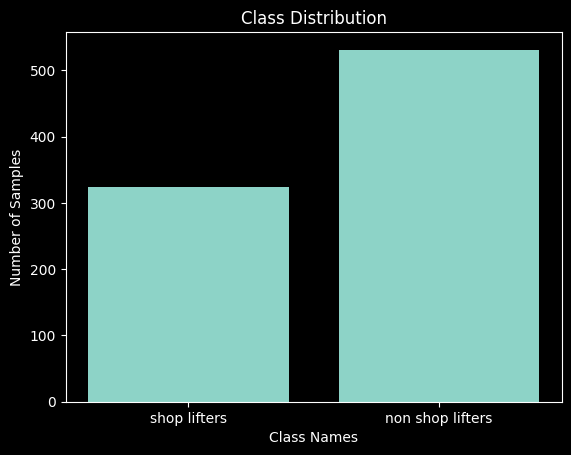

In [12]:
plt.bar(class_names, class_sample_counts)
plt.xlabel("Class Names")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")
plt.show()

## **Frames Distribution Visualization**

In [13]:
def get_frames_distribution(class_path):
  video_paths=[os.path.join(class_path,video_name) for video_name in os.listdir(class_path)]
  frames=[]
  for video_path in video_paths:
    cap=cv.VideoCapture(video_path)
    if cap.isOpened():
      frame_count = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
      frames.append(frame_count)
  return frames

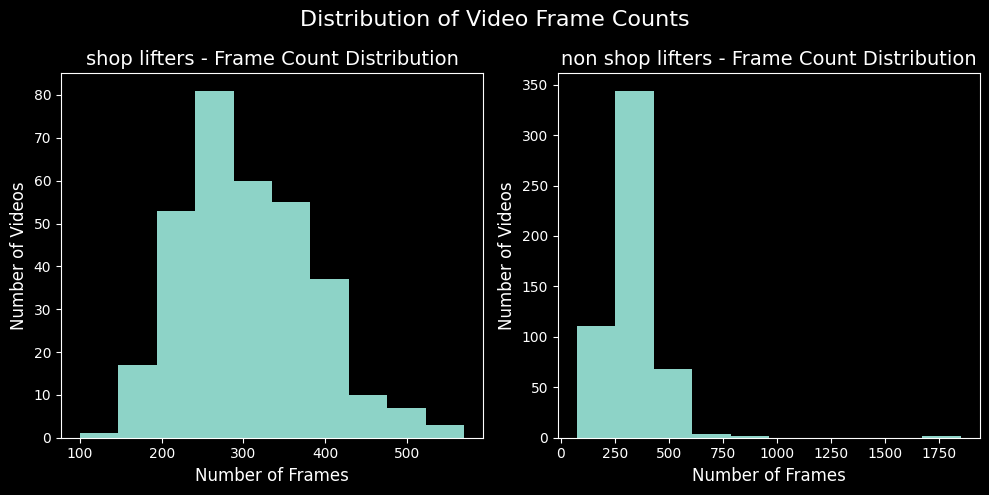

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for index in range(num_classes):
    frames = get_frames_distribution(class_paths[index])
    axes[index].hist(frames, bins=10)
    axes[index].set_xlabel("Number of Frames", fontsize=12)
    axes[index].set_ylabel("Number of Videos", fontsize=12)
    axes[index].set_title(f"{class_names[index]} - Frame Count Distribution", fontsize=14)

fig.suptitle("Distribution of Video Frame Counts", fontsize=16)
plt.tight_layout()
plt.show()

# **Preprocessing**

In [15]:
def preprocessing_video(video_path):
  cap=cv.VideoCapture(video_path)
  if not cap.isOpened():
    print("can not open this video")
    return
  frames=[]
  video_frame_count=int(cap.get(cv.CAP_PROP_FRAME_COUNT))
  skip_frames_window=max(int(video_frame_count/FRAMES ),1)
  for frame_counter in range(FRAMES ):
    cap.set(cv.CAP_PROP_POS_FRAMES,frame_counter*skip_frames_window)
    ret,frame=cap.read()
    if not ret:
      break
    # Convert BGR to RGB
    frame_rgb = cv.cvtColor(frame, cv.COLOR_BGR2RGB)
    # Resize Frames
    frame_resized=cv.resize(frame_rgb,(WIDTH,HEIGHT))
    # Normalize RGB
    frame_normalize = frame_resized.astype(np.float32) / 255.0
    frames.append(frame_normalize)
  cap.release()
  return np.array(frames)

In [16]:
features=[]
labels=[]

In [17]:
for class_index in range(num_classes):
  class_video_paths=[os.path.join(class_paths[class_index],video_name) for video_name in os.listdir(class_paths[class_index])]
  for video_path in class_video_paths:
    labels.append(class_index)
    frames=preprocessing_video(video_path)
    features.append(frames)

In [18]:
features=np.array(features)
labels=np.array(labels)

In [19]:
x_train,x_test,y_train,y_test=train_test_split(features,labels,test_size=0.3,shuffle=True,random_state=42)

In [20]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((598, 16, 128, 128, 3), (257, 16, 128, 128, 3), (598,), (257,))

In [21]:
x_val,x_test,y_val,y_test=train_test_split(x_test,y_test,test_size=0.5,shuffle=True,random_state=42)

In [22]:
x_val.shape,x_test.shape,y_val.shape,y_test.shape

((128, 16, 128, 128, 3), (129, 16, 128, 128, 3), (128,), (129,))

# Models

## CNN + RNN

In [23]:
# def build_cnn_rnn_model():
#     model = Sequential()
#     # CNN part
#     model.add(TimeDistributed(Conv2D(32, (3, 3), activation='relu', padding='same'), input_shape=(FRAMES, HEIGHT, WIDTH, 3)))
#     model.add(TimeDistributed(MaxPooling2D((2, 2))))
#     model.add(TimeDistributed(Conv2D(64, (3, 3), activation='relu', padding='same')))
#     model.add(TimeDistributed(MaxPooling2D((2, 2))))
#     model.add(TimeDistributed(Conv2D(128, (3, 3), activation='relu', padding='same')))
#     model.add(TimeDistributed(MaxPooling2D((2, 2))))
#     model.add(TimeDistributed(Flatten()))
#     # RNN part
#     model.add(LSTM(128, return_sequences=False))
#     model.add(Dense(64, activation='relu'))
#     model.add(Dropout(0.5))
#     model.add(Dense(num_classes, activation='softmax'))

#     model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
#     return model

In [24]:
# # Build and train
# cnn_rnn_model = build_cnn_rnn_model()
# cnn_rnn_model.summary()

# early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# cnn_rnn_history = cnn_rnn_model.fit(
#     x_train, y_train,
#     validation_data=(x_val, y_val),
#     epochs=20,
#     batch_size=16,
#     callbacks=[early_stopping]
# )

# # Evaluation
# cnn_rnn_test_loss, cnn_rnn_test_accuracy = cnn_rnn_model.evaluate(x_test, y_test)
# print(f"CNN+RNN Test Loss: {cnn_rnn_test_loss:.4f}, Test Accuracy: {cnn_rnn_test_accuracy:.4f}")

# # Predictions
# cnn_rnn_predictions = np.argmax(cnn_rnn_model.predict(x_test), axis=1)

In [25]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, MaxPooling3D, TimeDistributed, Dropout, Flatten, Dense, Conv3D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## CNN + LSTM

In [26]:
def build_convlstm2d_model():
    model = Sequential()
    model.add(ConvLSTM2D(filters=4, kernel_size=(3, 3), activation='tanh', data_format='channels_last',
                         recurrent_dropout=0.2, return_sequences=True, input_shape=(FRAMES, HEIGHT, WIDTH, 3)))
    model.add(MaxPooling3D(pool_size=(1, 2, 2), padding='same', data_format='channels_last'))
    model.add(TimeDistributed(Dropout(0.4)))

    model.add(ConvLSTM2D(filters=8, kernel_size=(3, 3), activation='tanh', data_format='channels_last',
                         recurrent_dropout=0.2, return_sequences=True))
    model.add(MaxPooling3D(pool_size=(1, 2, 2), padding='same', data_format='channels_last'))
    model.add(TimeDistributed(Dropout(0.4)))

    model.add(ConvLSTM2D(filters=14, kernel_size=(3, 3), activation='tanh', data_format='channels_last',
                         recurrent_dropout=0.2, return_sequences=True))
    model.add(MaxPooling3D(pool_size=(1, 2, 2), padding='same', data_format='channels_last'))
    model.add(TimeDistributed(Dropout(0.4)))

    # model.add(ConvLSTM2D(filters=16, kernel_size=(3, 3), activation='tanh', data_format='channels_last',
    #                      recurrent_dropout=0.2, return_sequences=True))
    # model.add(MaxPooling3D(pool_size=(1, 2, 2), padding='same', data_format='channels_last'))
    # model.add(TimeDistributed(Dropout(0.4)))

    model.add(Flatten())
    model.add(Dense(len(set(labels)), activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [27]:
# Build and train
convlstm2d_model = build_convlstm2d_model()
convlstm2d_model.summary()

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

convlstm2d_history = convlstm2d_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=16,
    callbacks=[early_stopping]
)

# Evaluation
convlstm2d_test_loss, convlstm2d_test_accuracy = convlstm2d_model.evaluate(x_test, y_test)
print(f"ConvLSTM2D Test Loss: {convlstm2d_test_loss:.4f}, Test Accuracy: {convlstm2d_test_accuracy:.4f}")

# Predictions
convlstm2d_predictions = np.argmax(convlstm2d_model.predict(x_test), axis=1)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 16, 126, 126,   │         1,024 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 16, 63, 63, 4)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 16, 63, 63, 4)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)      │ (None, 16, 61, 61, 8)  │         3,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 16, 31, 31, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 16, 31, 31, 8)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_2 (ConvLSTM2D)      │ (None, 16, 29, 29, 14) │        11,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 16, 15, 15, 14) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 16, 15, 15, 14) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │       100,802 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,458 (454.91 KB)

 Trainable params: 116,458 (454.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.5459 - loss: 0.8959 - val_accuracy: 0.6250 - val_loss: 0.6630
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 48s 237ms/step - accuracy: 0.6463 - loss: 0.6520 - val_accuracy: 0.6250 - val_loss: 0.6430
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 234ms/step - accuracy: 0.6283 - loss: 0.6350 - val_accuracy: 0.6250 - val_loss: 0.5654
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 233ms/step - accuracy: 0.7081 - loss: 0.5745 - val_accuracy: 0.9141 - val_loss: 0.3516
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 239ms/step - accuracy: 0.8682 - loss: 0.3134 - val_accuracy: 0.9531 - val_loss: 0.1507
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 243ms/step - accuracy: 0.9452 - loss: 0.1566 - val_accuracy: 0.9688 - val_loss: 0.0798
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 239ms/step - accuracy: 0.9233 - loss: 0.2006 - val_accuracy: 0.9844 - val_loss: 0.0650
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 244ms/step - accuracy: 0.9369 - loss: 0.1580 - val_accuracy: 

## 3D CNN

In [28]:
def build_3d_cnn_model():
    model = Sequential()
    model.add(Conv3D(32, (3, 3, 3), activation='relu', padding='same', input_shape=(FRAMES, HEIGHT, WIDTH, 3)))
    model.add(MaxPooling3D((2, 2, 2)))
    model.add(Conv3D(64, (3, 3, 3), activation='relu', padding='same'))
    model.add(MaxPooling3D((2, 2, 2)))
    model.add(Conv3D(128, (3, 3, 3), activation='relu', padding='same'))
    model.add(MaxPooling3D((2, 2, 2)))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.7))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [29]:
# Build and train
cnn_3d_model = build_3d_cnn_model()
cnn_3d_model.summary()

cnn_3d_history = cnn_3d_model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=16,
    callbacks=[early_stopping]
)

# Evaluation
cnn_3d_test_loss, cnn_3d_test_accuracy = cnn_3d_model.evaluate(x_test, y_test)
print(f"3D CNN Test Loss: {cnn_3d_test_loss:.4f}, Test Accuracy: {cnn_3d_test_accuracy:.4f}")

# Predictions
cnn_3d_predictions = np.argmax(cnn_3d_model.predict(x_test), axis=1)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 16, 128, 128,   │         2,624 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_3 (MaxPooling3D)  │ (None, 8, 64, 64, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 8, 64, 64, 64)  │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_4 (MaxPooling3D)  │ (None, 4, 32, 32, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 4, 32, 32, 128) │       221,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_5 (MaxPooling3D)  │ (None, 2, 16, 16, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,668,290 (33.07 MB)

 Trainable params: 8,668,290 (33.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 27s 437ms/step - accuracy: 0.5271 - loss: 0.9555 - val_accuracy: 0.6250 - val_loss: 0.6687
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 198ms/step - accuracy: 0.5997 - loss: 0.6879 - val_accuracy: 0.6250 - val_loss: 0.6753
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 197ms/step - accuracy: 0.6169 - loss: 0.6725 - val_accuracy: 0.6250 - val_loss: 0.6531
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 196ms/step - accuracy: 0.6129 - loss: 0.6466 - val_accuracy: 0.8750 - val_loss: 0.3255
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 198ms/step - accuracy: 0.8643 - loss: 0.3058 - val_accuracy: 0.9219 - val_loss: 0.2483
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 198ms/step - accuracy: 0.9544 - loss: 0.1880 - val_accuracy: 1.0000 - val_loss: 0.0323
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 215ms/step - accuracy: 0.9806 - loss: 0.0486 - val_accuracy: 1.0000 - val_loss: 0.0253
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 196ms/step - accuracy: 0.9832 - loss: 0.0692 - val_accura

## Models' Comparison (OLD)

In [30]:
# # Model Comparison

# # Plot training and validation accuracy
# plt.figure(figsize=(12, 5))

# plt.subplot(1, 2, 1)
# plt.plot(cnn_rnn_history.history['accuracy'], label='CNN+RNN Train Accuracy')
# plt.plot(cnn_rnn_history.history['val_accuracy'], label='CNN+RNN Val Accuracy')
# plt.plot(cnn_3d_history.history['accuracy'], label='3D CNN Train Accuracy')
# plt.plot(cnn_3d_history.history['val_accuracy'], label='3D CNN Val Accuracy')
# plt.title('Model Accuracy Comparison')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.legend()

# plt.subplot(1, 2, 2)
# plt.plot(cnn_rnn_history.history['loss'], label='CNN+RNN Train Loss')
# plt.plot(cnn_rnn_history.history['val_loss'], label='CNN+RNN Val Loss')
# plt.plot(cnn_3d_history.history['loss'], label='3D CNN Train Loss')
# plt.plot(cnn_3d_history.history['val_loss'], label='3D CNN Val Loss')
# plt.title('Model Loss Comparison')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()

# plt.tight_layout()
# plt.show()

# # Confusion Matrix for CNN+RNN
# plt.figure(figsize=(8, 6))
# cm_cnn_rnn = confusion_matrix(y_test, cnn_rnn_predictions)
# sns.heatmap(cm_cnn_rnn, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
# plt.title('CNN+RNN Confusion Matrix')
# plt.xlabel('Predicted')
# plt.ylabel('True')
# plt.show()

# # Confusion Matrix for 3D CNN
# plt.figure(figsize=(8, 6))
# cm_cnn_3d = confusion_matrix(y_test, cnn_3d_predictions)
# sns.heatmap(cm_cnn_3d, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
# plt.title('3D CNN Confusion Matrix')
# plt.xlabel('Predicted')
# plt.ylabel('True')
# plt.show()

# # Classification Report
# print("CNN+RNN Classification Report:")
# print(classification_report(y_test, cnn_rnn_predictions, target_names=class_names))

# print("3D CNN Classification Report:")
# print(classification_report(y_test, cnn_3d_predictions, target_names=class_names))

# # Summary of Results
# print("\nModel Comparison Summary:")
# print(f"CNN+RNN Model - Test Accuracy: {cnn_rnn_test_accuracy:.4f}, Test Loss: {cnn_rnn_test_loss:.4f}")
# print(f"3D CNN Model - Test Accuracy: {cnn_3d_test_accuracy:.4f}, Test Loss: {cnn_3d_test_loss:.4f}")

# if cnn_rnn_test_accuracy > cnn_3d_test_accuracy:
#     print("CNN+RNN model performed better based on test accuracy.")
# else:
#     print("3D CNN model performed better based on test accuracy.")

## Models' Comparison

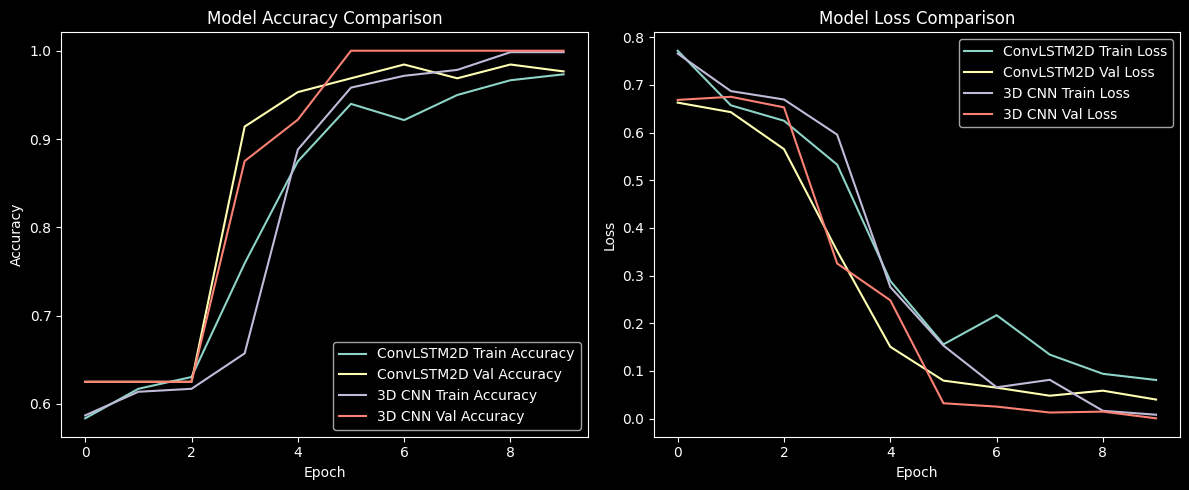

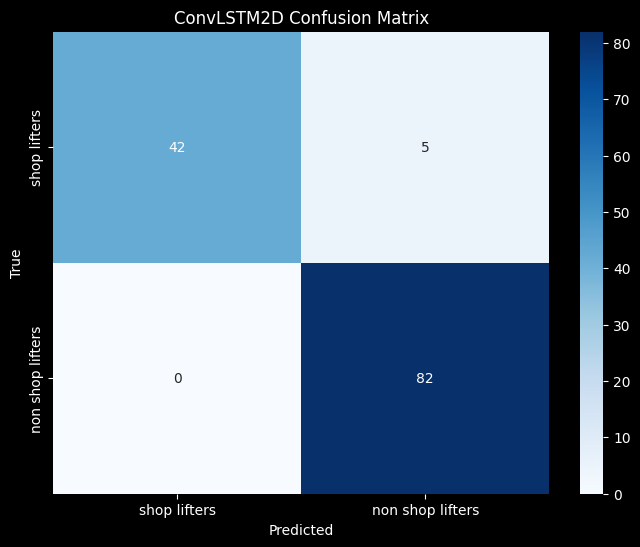

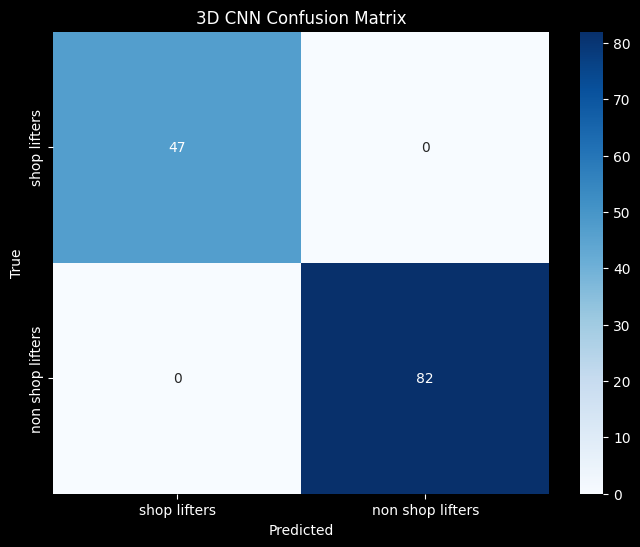

ConvLSTM2D Classification Report:
                  precision    recall  f1-score   support

    shop lifters       1.00      0.89      0.94        47
non shop lifters       0.94      1.00      0.97        82

        accuracy                           0.96       129
       macro avg       0.97      0.95      0.96       129
    weighted avg       0.96      0.96      0.96       129

3D CNN Classification Report:
                  precision    recall  f1-score   support

    shop lifters       1.00      1.00      1.00        47
non shop lifters       1.00      1.00      1.00        82

        accuracy                           1.00       129
       macro avg       1.00      1.00      1.00       129
    weighted avg       1.00      1.00      1.00       129


Model Comparison Summary:
ConvLSTM2D Model - Test Accuracy: 0.9612, Test Loss: 0.0760
3D CNN Model - Test Accuracy: 1.0000, Test Loss: 0.0050


In [31]:
# Plot training and validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(convlstm2d_history.history['accuracy'], label='ConvLSTM2D Train Accuracy')
plt.plot(convlstm2d_history.history['val_accuracy'], label='ConvLSTM2D Val Accuracy')
plt.plot(cnn_3d_history.history['accuracy'], label='3D CNN Train Accuracy')
plt.plot(cnn_3d_history.history['val_accuracy'], label='3D CNN Val Accuracy')
plt.title('Model Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(convlstm2d_history.history['loss'], label='ConvLSTM2D Train Loss')
plt.plot(convlstm2d_history.history['val_loss'], label='ConvLSTM2D Val Loss')
plt.plot(cnn_3d_history.history['loss'], label='3D CNN Train Loss')
plt.plot(cnn_3d_history.history['val_loss'], label='3D CNN Val Loss')
plt.title('Model Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Confusion Matrix for ConvLSTM2D
plt.figure(figsize=(8, 6))
cm_convlstm2d = confusion_matrix(y_test, convlstm2d_predictions)
sns.heatmap(cm_convlstm2d, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('ConvLSTM2D Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Confusion Matrix for 3D CNN
plt.figure(figsize=(8, 6))
cm_cnn_3d = confusion_matrix(y_test, cnn_3d_predictions)
sns.heatmap(cm_cnn_3d, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('3D CNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification Report
print("ConvLSTM2D Classification Report:")
print(classification_report(y_test, convlstm2d_predictions, target_names=class_names))

print("3D CNN Classification Report:")
print(classification_report(y_test, cnn_3d_predictions, target_names=class_names))

# Summary of Results
print("\nModel Comparison Summary:")
print(f"ConvLSTM2D Model - Test Accuracy: {convlstm2d_test_accuracy:.4f}, Test Loss: {convlstm2d_test_loss:.4f}")
print(f"3D CNN Model - Test Accuracy: {cnn_3d_test_accuracy:.4f}, Test Loss: {cnn_3d_test_loss:.4f}")